In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_val_score
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [2]:
SEED = 42
np.random.seed(SEED)

In [3]:
base = Path.cwd()
csv_path = base / 'outputs' / 'features' / 'features_V2.csv'
df = pd.read_csv(csv_path)
print("Shape :", df.shape)
print("Colonnes (5 premières) :", df.columns[:5].tolist())
print("Genres :", df["genre_top"].value_counts().to_dict())

# Vérifier où sont les NaN
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Colonnes avec NaN : {len(missing)}")
print(f"Total NaN : {df.isnull().sum().sum()}")
print(missing)

Shape : (7994, 362)
Colonnes (5 premières) : ['track_id', 'genre_top', 'genres', 'genres_decoded', 'n_subgenres']
Genres : {'Pop': 1000, 'Folk': 1000, 'International': 1000, 'Instrumental': 1000, 'Experimental': 999, 'Rock': 999, 'Electronic': 999, 'Hip-Hop': 997}
Colonnes avec NaN : 100
Total NaN : 104
chroma_stft_08_kurtosis    2
chroma_stft_08_skew        2
chroma_stft_01_skew        2
chroma_stft_01_kurtosis    2
mfcc_03_skew               1
                          ..
tonnetz_05_kurtosis        1
tonnetz_06_skew            1
tonnetz_06_kurtosis        1
zcr_01_skew                1
zcr_01_kurtosis            1
Length: 100, dtype: int64


In [4]:
NON_FEATURE_COLS = [
    'genre_top', 'genres', 'genres_decoded', 'n_subgenres',
    'mismatch', 'artist_name', 'track_title',
    'year', 'duration', 'bit_rate', 'track_id',
]

# Liste des colonnes qui ne sont pas des features audios
# ou des metadatas
# ou l'identifiant arbitraire track_id

X = df.drop(columns=NON_FEATURE_COLS)
X = X.select_dtypes(include=[np.number]) 
# Garder uniquement les colonnes numériques
y = df["genre_top"]
groups = df["artist_name"]

# Créations de trois objects distincts
# x contient les features audios
# y est la prédiction à faire (le genre)
# group contient les artistes qu'on donne au splitter pour éviter les fuites de données

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("X shape :", X.shape)
print("y distribution :\n", label_encoder.classes_)
print("Nombre d'artistes uniques :", groups.nunique())
print("NaN dans X (avant correction) :", X.isna().sum().sum())

X shape : (7994, 351)
y distribution :
 ['Electronic' 'Experimental' 'Folk' 'Hip-Hop' 'Instrumental'
 'International' 'Pop' 'Rock']
Nombre d'artistes uniques : 2304
NaN dans X (avant correction) : 104


In [5]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
# création du splitter
# 1 seul split (80% train, 20% test), avec un random state pour la reproductibilité

train_idx, test_idx = next(gss.split(X, y, groups=groups))
# on génère les indices de train et test à partir du splitter
# le splitter s'assure que les artistes ne sont pas partagés entre train et test

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
# extraction des données

print(f"Train : {len(X_train)} pistes — Test : {len(X_test)} pistes")
print("Distribution train :", pd.Series(y_train).value_counts().to_dict())
print("Distribution test  :", pd.Series(y_test).value_counts().to_dict())
# vérification de la répartition des classes dans les sets train et test

# Assertion anti-leakage
artists_train = set(groups.iloc[train_idx])
artists_test  = set(groups.iloc[test_idx])
overlap = artists_train & artists_test
assert len(overlap) == 0, f"Overlap artistes train/test détecté : {overlap}"
print("Group split validé — aucun artiste en commun entre train et test")

results_dir = base / 'outputs' / 'resultats'
results_dir.mkdir(parents=True, exist_ok=True)
np.save(results_dir / 'train_idx.npy', train_idx)
np.save(results_dir / 'test_idx.npy', test_idx)
print("train_idx.npy / test_idx.npy sauvegardés dans outputs/resultats/")

Train : 6477 pistes — Test : 1517 pistes
Distribution train : {2: 881, 6: 872, 4: 830, 7: 829, 1: 800, 3: 764, 5: 751, 0: 750}
Distribution test  : {5: 249, 0: 249, 3: 233, 1: 199, 7: 170, 4: 170, 6: 128, 2: 119}
Group split validé — aucun artiste en commun entre train et test
train_idx.npy / test_idx.npy sauvegardés dans outputs/resultats/


Le preprocessing permet de faire une imputation uniquement sur le train et empêcher le data leakage vers le train.

On impute les deux modèles, mais on ne va scale que le modèle Logistic Regression

In [6]:
# Pipeline LR : imputer (médiane) + RobustScaler + LogisticRegression
pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('clf', LogisticRegression(
        max_iter=2000,
        C=0.1,
        solver='lbfgs',
        class_weight='balanced',
        random_state=SEED,
    )),
])

# Pipeline RF : imputer (médiane) uniquement, RF invariant au scaling
pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        n_estimators=300,  
        max_depth=20,
        min_samples_leaf=4,
        max_features='sqrt',
        class_weight='balanced',
        random_state=SEED,
    )),
])

print("Pipelines définies")

Pipelines définies


In [7]:
import time

t0 = time.time()
pipe_lr.fit(X_train, y_train)
y_pred_lr = pipe_lr.predict(X_test)
duration_lr = round(time.time() - t0, 1)

f1_lr  = f1_score(y_test, y_pred_lr, average='macro')
acc_lr = accuracy_score(y_test, y_pred_lr)
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)

print(f"F1 macro  : {f1_lr:.4f}")
print(f"Accuracy  : {acc_lr:.4f}")
print(f"Bal. Acc. : {bal_acc_lr:.4f}") 
# détecte si le modèle sacrifie certaines classes
print(f"Durée     : {duration_lr}s")
print()
print("Rapport détaillé :")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

F1 macro  : 0.4579
Accuracy  : 0.4733
Bal. Acc. : 0.4621
Durée     : 1.5s

Rapport détaillé :
               precision    recall  f1-score   support

   Electronic       0.47      0.57      0.52       249
 Experimental       0.45      0.37      0.41       199
         Folk       0.42      0.52      0.46       119
      Hip-Hop       0.61      0.53      0.57       233
 Instrumental       0.38      0.41      0.39       170
International       0.57      0.46      0.51       249
          Pop       0.23      0.23      0.23       128
         Rock       0.55      0.60      0.57       170

     accuracy                           0.47      1517
    macro avg       0.46      0.46      0.46      1517
 weighted avg       0.48      0.47      0.47      1517



In [8]:
groups_train = groups.iloc[train_idx]
gkf = GroupKFold(n_splits=5)

cv_scores_lr = cross_val_score(
    pipe_lr, X_train, y_train,
    cv=gkf,
    scoring='f1_macro',
    groups=groups_train,
)
print(f"CV F1 macro (5 folds GroupKFold) : {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}")
print("Scores par fold :", cv_scores_lr.round(4))

CV F1 macro (5 folds GroupKFold) : 0.4740 ± 0.0169
Scores par fold : [0.5036 0.4757 0.4522 0.4728 0.4656]


In [9]:
t0 = time.time()
pipe_rf.fit(X_train, y_train)
y_pred_rf = pipe_rf.predict(X_test)
duration_rf = round(time.time() - t0, 1)

f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
acc_rf = accuracy_score(y_test, y_pred_rf)
bal_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)

print(f"F1 macro  : {f1_rf:.4f}")
print(f"Accuracy  : {acc_rf:.4f}")
print(f"Bal. Acc. : {bal_acc_rf:.4f}")
print(f"Durée     : {duration_rf}s")
print()
print("Rapport détaillé :")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

F1 macro  : 0.4580
Accuracy  : 0.4693
Bal. Acc. : 0.4709
Durée     : 14.2s

Rapport détaillé :
               precision    recall  f1-score   support

   Electronic       0.49      0.49      0.49       249
 Experimental       0.55      0.35      0.43       199
         Folk       0.49      0.69      0.57       119
      Hip-Hop       0.58      0.56      0.57       233
 Instrumental       0.40      0.53      0.45       170
International       0.51      0.37      0.43       249
          Pop       0.15      0.16      0.16       128
         Rock       0.52      0.61      0.56       170

     accuracy                           0.47      1517
    macro avg       0.46      0.47      0.46      1517
 weighted avg       0.48      0.47      0.47      1517



In [10]:
cv_scores_rf = cross_val_score(
    pipe_rf, X_train, y_train,
    cv=gkf,
    scoring='f1_macro',
    groups=groups_train,
)
print(f"CV F1 macro (5 folds GroupKFold) : {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}")
print("Scores par fold :", cv_scores_rf.round(4))

CV F1 macro (5 folds GroupKFold) : 0.4728 ± 0.0126
Scores par fold : [0.4765 0.4828 0.4793 0.4481 0.4773]


In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'clf__n_estimators': [300],
    'clf__max_depth': [10, 20, 30],
    'clf__min_samples_leaf': [4, 8],
}

# Pipeline RF pour GridSearch
pipe_rf_gs = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(
        max_features='sqrt',
        class_weight='balanced',
        random_state=SEED,
    )),
])

grid = GridSearchCV(
    pipe_rf_gs,
    param_grid,
    cv=GroupKFold(n_splits=5),
    scoring='f1_macro',
    verbose=1,
)
grid.fit(X_train, y_train, groups=groups_train)

print('Meilleurs params :', grid.best_params_)
print('Meilleur F1 CV   :', round(grid.best_score_, 4))

# Utiliser le meilleur modèle pour les prédictions finales RF
y_pred_rf = grid.best_estimator_.predict(X_test)
f1_rf  = f1_score(y_test, y_pred_rf, average='macro')
acc_rf = accuracy_score(y_test, y_pred_rf)
bal_acc_rf = balanced_accuracy_score(y_test, y_pred_rf)

print(f"\nRF optimisé — F1 macro test : {f1_rf:.4f}")
print(f"RF optimisé — Accuracy test  : {acc_rf:.4f}")
print(f"RF optimisé — Bal. Acc. test : {bal_acc_rf:.4f}")
print()
print("Rapport détaillé (RF optimisé) :")
print(classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_))

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Meilleurs params : {'clf__max_depth': 20, 'clf__min_samples_leaf': 4, 'clf__n_estimators': 300}
Meilleur F1 CV   : 0.4728

RF optimisé — F1 macro test : 0.4580
RF optimisé — Accuracy test  : 0.4693
RF optimisé — Bal. Acc. test : 0.4709

Rapport détaillé (RF optimisé) :
               precision    recall  f1-score   support

   Electronic       0.49      0.49      0.49       249
 Experimental       0.55      0.35      0.43       199
         Folk       0.49      0.69      0.57       119
      Hip-Hop       0.58      0.56      0.57       233
 Instrumental       0.40      0.53      0.45       170
International       0.51      0.37      0.43       249
          Pop       0.15      0.16      0.16       128
         Rock       0.52      0.61      0.56       170

     accuracy                           0.47      1517
    macro avg       0.46      0.47      0.46      1517
 weighted avg       0.48      0.47      0.47      1517



In [12]:
# GridSearch — Logistic Regression
param_grid_lr = {
    'clf__C': [0.01, 0.1, 1, 10],
}

pipe_lr_gs = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler()),
    ('clf', LogisticRegression(
        solver='lbfgs',
        max_iter=2000,
        class_weight='balanced',
        random_state=SEED,
    )),
])

grid_lr = GridSearchCV(
    pipe_lr_gs,
    param_grid_lr,
    cv=GroupKFold(n_splits=5),
    scoring='f1_macro',
    verbose=1,
)
grid_lr.fit(X_train, y_train, groups=groups_train)

print('Meilleurs params LR :', grid_lr.best_params_)
print('Meilleur F1 CV LR   :', round(grid_lr.best_score_, 4))

# Prédictions finales LR optimisé
y_pred_lr = grid_lr.best_estimator_.predict(X_test)
f1_lr  = f1_score(y_test, y_pred_lr, average='macro')
acc_lr = accuracy_score(y_test, y_pred_lr)
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)

print(f"\nLR optimisé — F1 macro test : {f1_lr:.4f}")
print(f"LR optimisé — Accuracy test  : {acc_lr:.4f}")
print(f"LR optimisé — Bal. Acc. test : {bal_acc_lr:.4f}")
print()
print("Rapport détaillé (LR optimisé) :")
print(classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_))

Fitting 5 folds for each of 4 candidates, totalling 20 fits
Meilleurs params LR : {'clf__C': 0.01}
Meilleur F1 CV LR   : 0.477

LR optimisé — F1 macro test : 0.4656
LR optimisé — Accuracy test  : 0.4819
LR optimisé — Bal. Acc. test : 0.4702

Rapport détaillé (LR optimisé) :
               precision    recall  f1-score   support

   Electronic       0.43      0.54      0.48       249
 Experimental       0.48      0.37      0.42       199
         Folk       0.43      0.54      0.48       119
      Hip-Hop       0.65      0.56      0.60       233
 Instrumental       0.40      0.43      0.41       170
International       0.59      0.49      0.53       249
          Pop       0.21      0.20      0.20       128
         Rock       0.56      0.64      0.60       170

     accuracy                           0.48      1517
    macro avg       0.47      0.47      0.47      1517
 weighted avg       0.49      0.48      0.48      1517



In [13]:
# Comparaison des modèles
results = [
    {
        'model': 'Logistic Regression',
        'f1_test': round(f1_lr, 4),
        'acc_test': round(acc_lr, 4),
        'bal_acc_test': round(bal_acc_lr, 4),
        'f1_cv_mean': round(cv_scores_lr.mean(), 4),
        'f1_cv_std': round(cv_scores_lr.std(), 4),
        'duration_s': duration_lr,
        'seed': SEED,
        'split': 'GroupShuffleSplit',
        'imputer': 'median',
        'scaler': 'RobustScaler',
        'n_features': X_train.shape[1],
        'n_train': len(train_idx),
        'n_test': len(test_idx),
        'dataset': 'FMA_Small',
    },
    {
        'model': 'Random Forest',
        'f1_test': round(f1_rf, 4),
        'acc_test': round(acc_rf, 4),
        'bal_acc_test': round(bal_acc_rf, 4),
        'f1_cv_mean': round(cv_scores_rf.mean(), 4),
        'f1_cv_std': round(cv_scores_rf.std(), 4),
        'duration_s': duration_rf,
        'seed': SEED,
        'split': 'GroupShuffleSplit',
        'imputer': 'median',
        'scaler': 'None',
        'n_features': X_train.shape[1],
        'n_train': len(train_idx),
        'n_test': len(test_idx),
        'dataset': 'FMA_Small',
    },
]
df_results = pd.DataFrame(results)
print("TABLEAU COMPARATIF")
print(df_results[['model', 'f1_test', 'acc_test', 'bal_acc_test', 'f1_cv_mean', 'f1_cv_std']].to_string(index=False))

# Export CSV — format commun au groupe
results_dir = base / 'outputs' / 'resultats'
results_dir.mkdir(parents=True, exist_ok=True)
df_results.to_csv(results_dir / 'results_nb3.csv', index=False)
print(f"\nrésultats exportés dans outputs/resultats/results_nb3.csv")

TABLEAU COMPARATIF
              model  f1_test  acc_test  bal_acc_test  f1_cv_mean  f1_cv_std
Logistic Regression   0.4656    0.4819        0.4702      0.4740     0.0169
      Random Forest   0.4580    0.4693        0.4709      0.4728     0.0126

résultats exportés dans outputs/resultats/results_nb3.csv


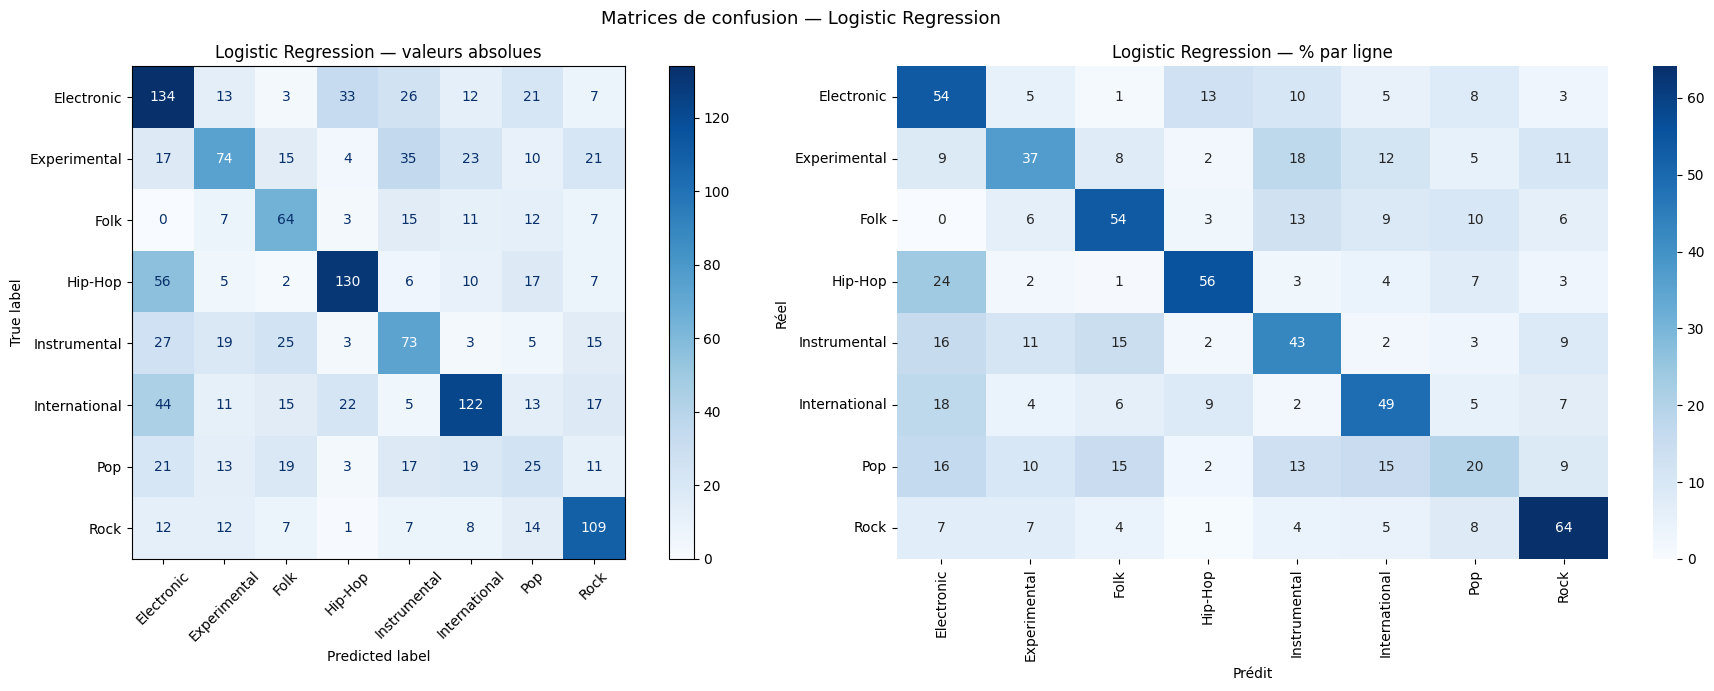

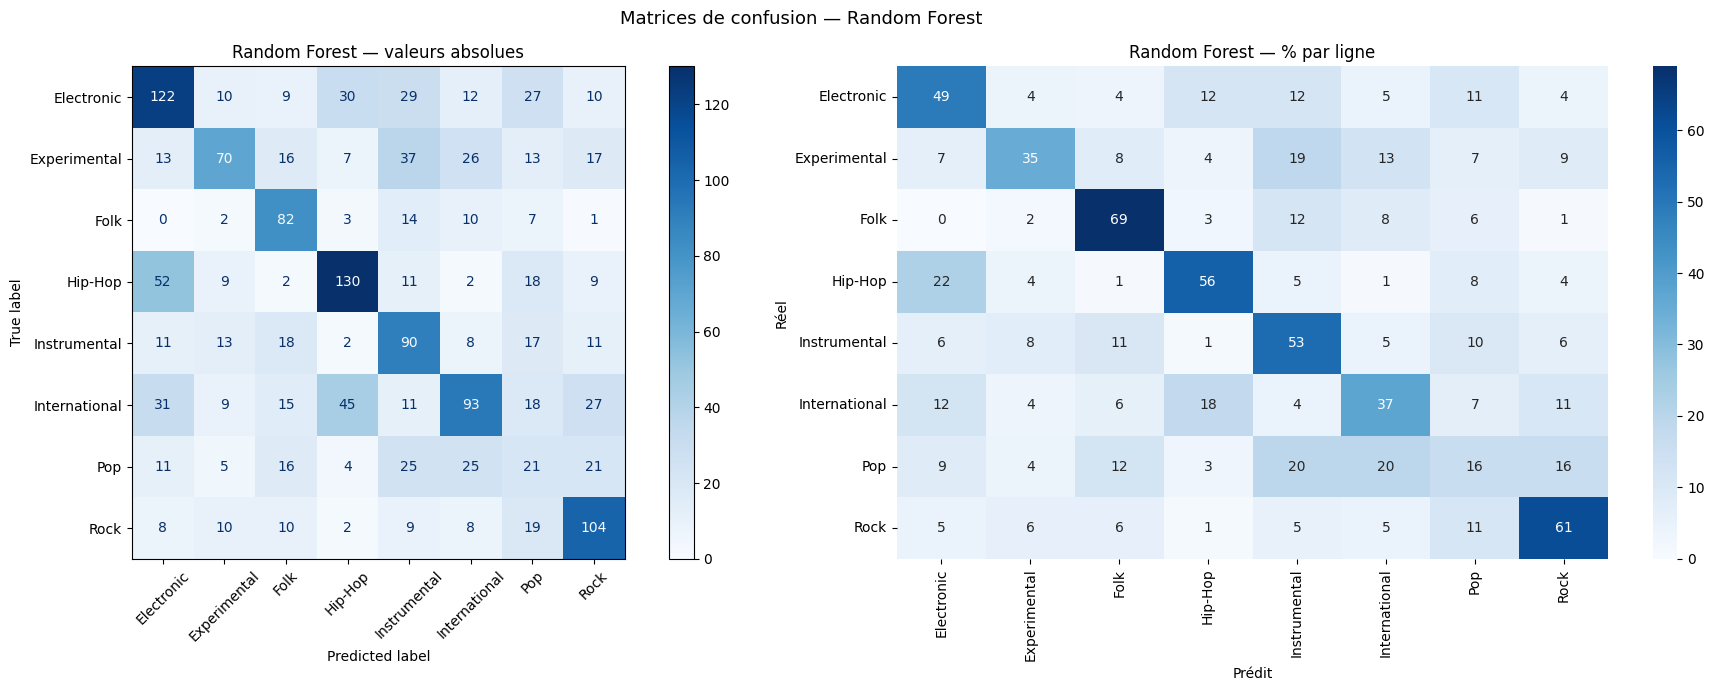

In [14]:
# Martrice de confusion pour la régression logistique
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_lr_pct = cm_lr.astype(float) / cm_lr.sum(axis=1, keepdims=True) * 100
# calcule la matrice en valeurs absolue
# puis normalisation en pourcentage par ligne
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
# Valeurs absolues
labels_str = label_encoder.classes_
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=labels_str)
disp.plot(ax=axes[0], colorbar=True, cmap='Blues', xticks_rotation=45)
axes[0].set_title("Logistic Regression — valeurs absolues")
# Pourcentages par ligne
sns.heatmap(cm_lr_pct, annot=True, fmt=".0f",
            xticklabels=labels_str, yticklabels=labels_str,
            cmap='Blues', ax=axes[1])
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")
axes[1].set_title("Logistic Regression — % par ligne")
plt.suptitle("Matrices de confusion — Logistic Regression", fontsize=13)
plt.tight_layout()
plt.show()

# Même chose pour le Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf_pct = cm_rf.astype(float) / cm_rf.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=labels_str)
disp.plot(ax=axes[0], colorbar=True, cmap='Blues', xticks_rotation=45)
axes[0].set_title("Random Forest — valeurs absolues")
sns.heatmap(cm_rf_pct, annot=True, fmt=".0f",
            xticklabels=labels_str, yticklabels=labels_str,
            cmap='Blues', ax=axes[1])
axes[1].set_xlabel("Prédit")
axes[1].set_ylabel("Réel")
axes[1].set_title("Random Forest — % par ligne")
plt.suptitle("Matrices de confusion — Random Forest", fontsize=13)
plt.tight_layout()
plt.show()

ANALYSE MISMATCH × RECALL
        Genre  Mismatch_%  Recall_LR  F1_LR  Recall_RF  F1_RF
      Hip-Hop        12.4      0.558  0.602      0.558  0.570
         Folk        22.8      0.538  0.476      0.689  0.571
 Instrumental        36.3      0.429  0.412      0.529  0.455
 Experimental        41.5      0.372  0.419      0.352  0.428
          Pop        42.6      0.195  0.204      0.164  0.157
   Electronic        47.0      0.538  0.479      0.490  0.491
         Rock        63.9      0.641  0.599      0.612  0.562
International        68.0      0.490  0.534      0.373  0.430


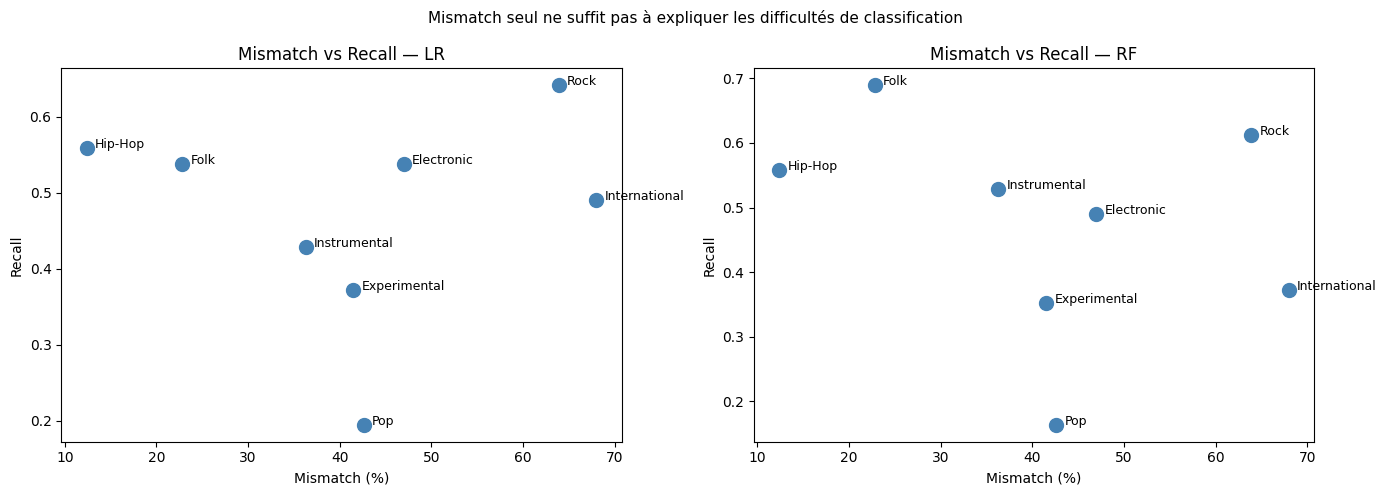

In [15]:
# Analyse des erreurs
# Recalcul depuis le df, robuste si les données changent
mismatch_by_genre = df.groupby('genre_top')['mismatch'].mean() * 100

# Rapport RF avec noms de genres
report_rf = classification_report(y_test, y_pred_rf, target_names=label_encoder.classes_, output_dict=True)
report_lr = classification_report(y_test, y_pred_lr, target_names=label_encoder.classes_, output_dict=True)

analysis = pd.DataFrame({
    'Genre'      : label_encoder.classes_,
    'Mismatch_%' : [round(mismatch_by_genre.get(g, np.nan), 1) for g in label_encoder.classes_],
    'Recall_LR'  : [round(report_lr[g]['recall'], 3) for g in label_encoder.classes_],
    'F1_LR'      : [round(report_lr[g]['f1-score'], 3) for g in label_encoder.classes_],
    'Recall_RF'  : [round(report_rf[g]['recall'], 3) for g in label_encoder.classes_],
    'F1_RF'      : [round(report_rf[g]['f1-score'], 3) for g in label_encoder.classes_],
}).sort_values('Mismatch_%')

print("ANALYSE MISMATCH × RECALL")
print(analysis.to_string(index=False))

# Scatter plot mismatch vs recall (LR et RF côte à côte)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, model, col_recall in zip(axes, ['LR', 'RF'], ['Recall_LR', 'Recall_RF']):
    ax.scatter(analysis['Mismatch_%'], analysis[col_recall], s=100, color='steelblue')
    for _, row in analysis.iterrows():
        ax.annotate(row['Genre'], (row['Mismatch_%'], row[col_recall]),
                    textcoords='offset points', xytext=(6, 0), fontsize=9)
    ax.set_xlabel('Mismatch (%)')
    ax.set_ylabel('Recall')
    ax.set_title(f'Mismatch vs Recall — {model}')
plt.suptitle("Mismatch seul ne suffit pas à expliquer les difficultés de classification", fontsize=11)
plt.tight_layout()
plt.show()
# Plus le mismatch est élevé, moins le modèle performe

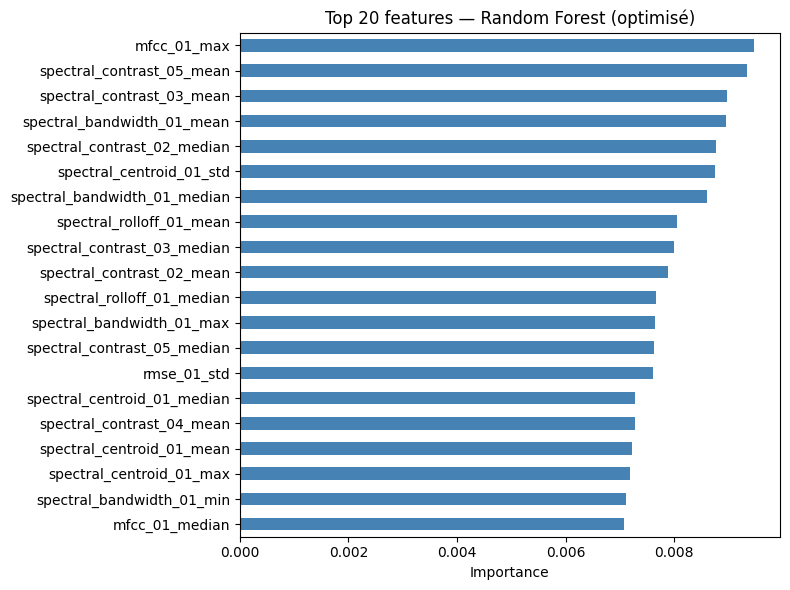

Top 20 features :
mfcc_01_max                     0.0095
spectral_contrast_05_mean       0.0093
spectral_contrast_03_mean       0.0090
spectral_bandwidth_01_mean      0.0089
spectral_contrast_02_median     0.0088
spectral_centroid_01_std        0.0087
spectral_bandwidth_01_median    0.0086
spectral_rolloff_01_mean        0.0081
spectral_contrast_03_median     0.0080
spectral_contrast_02_mean       0.0079
spectral_rolloff_01_median      0.0077
spectral_bandwidth_01_max       0.0077
spectral_contrast_05_median     0.0076
rmse_01_std                     0.0076
spectral_centroid_01_median     0.0073
spectral_contrast_04_mean       0.0073
spectral_centroid_01_mean       0.0072
spectral_centroid_01_max        0.0072
spectral_bandwidth_01_min       0.0071
mfcc_01_median                  0.0071


In [16]:
# Extraction du RF depuis le pipeline optimisé
rf_best = grid.best_estimator_.named_steps['clf']
# Récupérer les noms de features après imputation (identiques à X.columns)
feat_imp = pd.Series(rf_best.feature_importances_, index=X.columns)
top20 = feat_imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(8, 6))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title("Top 20 features — Random Forest (optimisé)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

print("Top 20 features :")
print(top20.round(4).to_string())